In [570]:
import torch
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from torch.nn import MSELoss
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

np.random.seed(42)
plt.style.use("default")

In [571]:
print(torch.cuda.is_available())

True


In [572]:
print(f"{torch.cuda.get_device_name(0)}")

NVIDIA GeForce GTX 1650


In [573]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

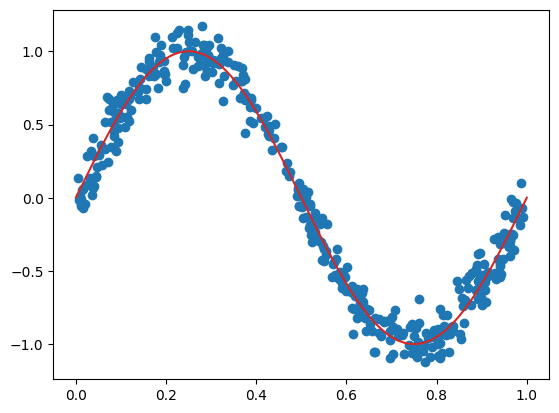

In [574]:
X = np.random.uniform(size=(500,1))
y = np.sin(2 * np.pi * X) + np.random.randn(*X.shape) * 0.1

X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test = y_test.cpu()

plt.scatter(X_train.cpu(), y_train.cpu())
plt.plot(np.linspace(0, 1, 100), np.sin(2 * np.pi * np.linspace(0, 1, 100)), c="tab:red")

In [575]:
trainds = TensorDataset(X_train, y_train)
train_loader = DataLoader(trainds, batch_size=128, shuffle=True)

In [576]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        n_layers = 4
        hls = 8
        self.relu = nn.ReLU()

        # self.layer1 = nn.Linear(1, hls)
        self.net = nn.Sequential(
            nn.Linear(1, hls),
            self.relu,

            *[nn.Sequential(
                nn.Linear(hls, hls),
                self.relu
            ) for _ in range(n_layers-2)],

            nn.Linear(hls, 1),
        )
        # self.h1 = nn.Linear(hls, hls)
        # self.h2 = nn.Linear(hls, hls)
        # self.h3 = nn.Linear(hls, hls)

        # self.layerOut = nn.Linear(hls, 1)

    def forward(self, x):
        x = self.net(x)
        return x

In [577]:
model = MLP()
model.to(device)

loss_fn = MSELoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

total_epochs = 500
total_reports = 10
report_every = total_epochs // total_reports

for epoch in range(1000):
    for data, target in train_loader:
        optimizer.zero_grad()

        y_pred = model(data)

        loss = loss_fn(y_pred, target)
        loss.backward()

        optimizer.step()

    if epoch % report_every == 0:
        model.eval()
        with torch.no_grad():
            y_pred = model(X_test)
            error = y_test - y_pred.detach().cpu()
            MSE = (error**2).mean()
            print(f"{epoch=}\t{MSE=:.3f}")
        model.train()

model.eval()

epoch=0	MSE=0.475
epoch=50	MSE=0.182
epoch=100	MSE=0.123
epoch=150	MSE=0.099
epoch=200	MSE=0.072
epoch=250	MSE=0.051
epoch=300	MSE=0.036
epoch=350	MSE=0.023
epoch=400	MSE=0.017
epoch=450	MSE=0.014
epoch=500	MSE=0.013
epoch=550	MSE=0.013
epoch=600	MSE=0.012
epoch=650	MSE=0.012
epoch=700	MSE=0.012
epoch=750	MSE=0.012
epoch=800	MSE=0.011
epoch=850	MSE=0.013
epoch=900	MSE=0.012
epoch=950	MSE=0.012


MLP(
  (relu): ReLU()
  (net): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Sequential(
      (0): Linear(in_features=8, out_features=8, bias=True)
      (1): ReLU()
    )
    (3): Sequential(
      (0): Linear(in_features=8, out_features=8, bias=True)
      (1): ReLU()
    )
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

MSE=0.012


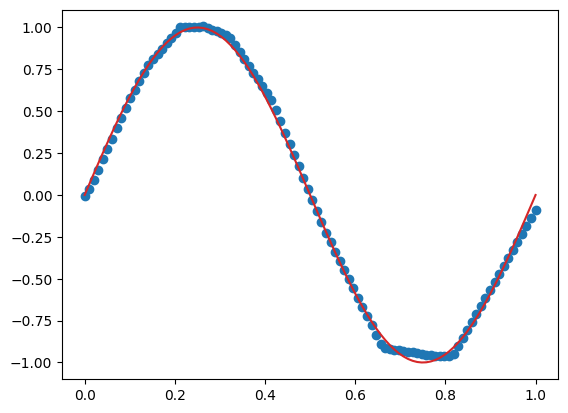

In [578]:
model.eval()

y_pred = model(X_test)
error = y_test - y_pred.detach().cpu()
MSE = (error**2).mean()
print(f"{MSE=:.3f}")

X_plot = torch.Tensor(np.linspace(0, 1, 100))
plt.scatter(X_plot, model(X_plot.reshape(-1, 1).to(device)).detach().cpu())
plt.plot(X_plot, np.sin(2 * np.pi * X_plot), c="tab:red")


In [579]:
for l in model.state_dict().values():
    print(l)

tensor([[-0.1166],
        [ 1.0932],
        [-0.0094],
        [ 1.3020],
        [ 1.0102],
        [-1.2571],
        [ 0.6819],
        [-1.0105]], device='cuda:0')
tensor([-0.3211, -0.2905, -0.2846, -0.4106,  0.3860,  0.4616,  0.9137,  0.7895],
       device='cuda:0')
tensor([[ 0.2340,  1.1465,  0.0489,  1.1237, -0.7059,  0.5331,  0.0321,  0.4459],
        [-0.3505, -0.2309, -0.2902, -0.3503, -0.1322, -0.0891, -0.3280, -0.3361],
        [-0.3065, -0.5223,  0.2091, -0.4255,  0.3110, -0.5598, -0.0262,  0.1414],
        [ 0.2349,  0.0177, -0.2588, -0.3309, -0.2730,  0.2273, -0.2039, -0.1154],
        [-0.0393,  0.0296,  0.2813, -0.6710,  0.3313, -0.5713,  0.0590, -0.3645],
        [-0.2098, -0.6693, -0.0773, -0.5944,  0.0712,  0.3335, -0.0811,  0.0782],
        [ 0.2438, -0.4577, -0.3449, -0.7141, -0.3745,  0.9615,  0.0586,  0.6516],
        [-0.0423, -0.3417, -0.0114, -0.9056,  0.1631, -0.2085,  0.4067,  0.1591]],
       device='cuda:0')
tensor([ 0.0300,  0.3417,  0.4053, -0.2984, 